# Table of Contents
* [Instructions](#Instructions)
* [Python Import](#Python-Import)
* [Working with Homogeneous Image](#Working-with-Homogeneous-Image)
	* [Load and Preview of data](#Load-and-Preview-of-data)
	* [Retrieve or Define Data Characteristics](#Retrieve-or-Define-Data-Characteristics)
	* [Loop Over all Slices and Correct Geometry](#Loop-Over-all-Slices-and-Correct-Geometry)
		* [Truncate Data to Keep Only Object](#Truncate-Data-to-Keep-Only-Object)
		* [Test Result by Plotting a Slice](#Test-Result-by-Plotting-a-Slice)
		* [Put Back Object Inside Image](#Put-Back-Object-Inside-Image)
		* [Output Corrected Image](#Output-Corrected-Image)
* [Working with Inomogeneous Image](#Working-with-Inomogeneous-Image)
	* [Data of Interest are in the Outer Ring](#Data-of-Interest-are-in-the-Outer-Ring)
		* [Load and Preview of data](#Load-and-Preview-of-data)
		* [Retrieve or Define Data Characteristics](#Retrieve-or-Define-Data-Characteristics)
		* [Loop Over all Slices and Correct Geometry](#Loop-Over-all-Slices-and-Correct-Geometry)
			* [Truncate Data to Keep Only Object](#Truncate-Data-to-Keep-Only-Object)
			* [Test Result by Plotting a Slice](#Test-Result-by-Plotting-a-Slice)
			* [Put Back Object Inside Image](#Put-Back-Object-Inside-Image)
		* [Output Corrected Image](#Output-Corrected-Image)
	* [Data of Interest are in the Inner Cylinder](#Data-of-Interest-are-in-the-Inner-Cylinder)
		* [Load and Preview of data](#Load-and-Preview-of-data)
		* [Retrieve or Define Data Characteristics](#Retrieve-or-Define-Data-Characteristics)
		* [Loop Over all Slices and Correct Geometry](#Loop-Over-all-Slices-and-Correct-Geometry)
			* [Truncate Data to Keep Only Object](#Truncate-Data-to-Keep-Only-Object)
			* [Test Result by Plotting a Slice](#Test-Result-by-Plotting-a-Slice)
			* [Put Back Object Inside Image](#Put-Back-Object-Inside-Image)
		* [Output Corrected Image](#Output-Corrected-Image)


# Instructions 

This notebook will load real fits and tiff cylindrical sample images and will test the algorithm to make sure we get a nice constant profile at the end.

# Python Import

In [1]:
from plotly.offline import plot, init_notebook_mode, iplot
init_notebook_mode()
import plotly.graph_objects as go
from plotly import tools

import numpy as np

from IPython.display import Image
from IPython.core.display import HTML

import matplotlib.pyplot as plt
%matplotlib inline

from neutron_geomcorr import file_handler
from neutron_geomcorr import geometry_correction

# Working with Homogeneous Image

## Load and Preview of data

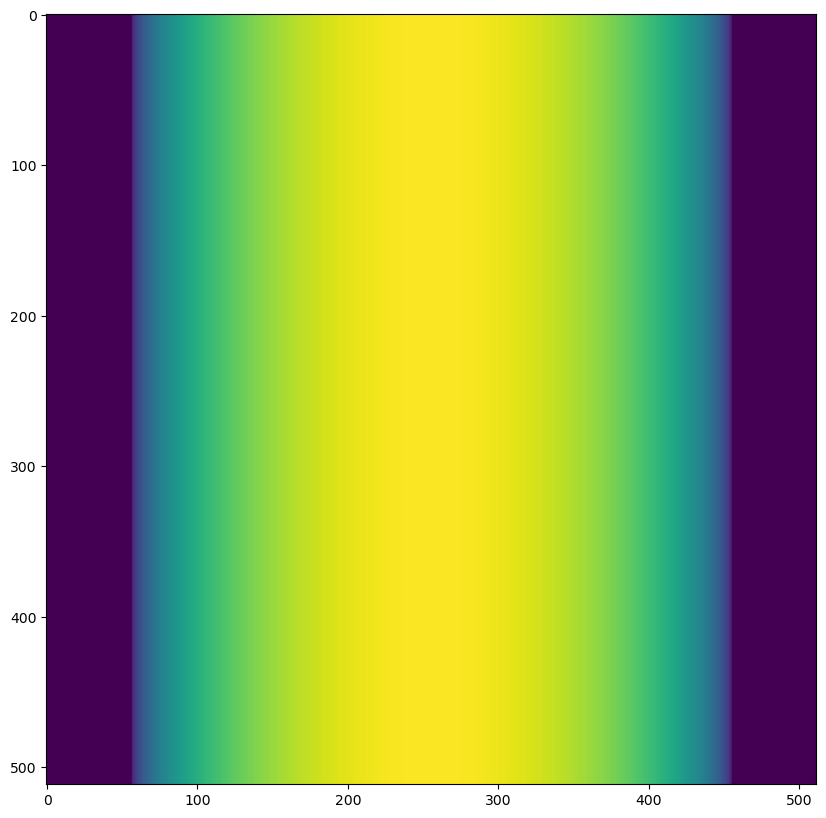

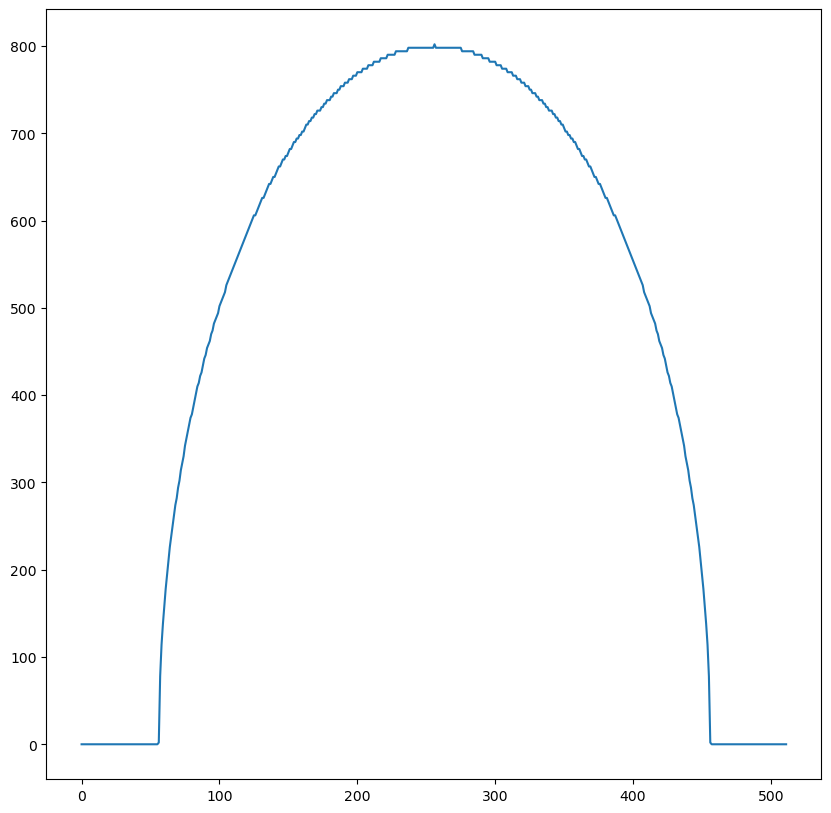

In [2]:
test_homogeneous_file = 'data/fits/homogeneous_image_px_intensity_2.fits'
homogeneous_image = file_handler.load_fits(test_homogeneous_file)

#test_homogeneous_file = 'data/homogeneous_image.tif'
#homogeneous_image = file_handler.load_tiff(test_homogeneous_file)
#homogeneous_image = homogeneous_image[:,:,0]

fig =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(homogeneous_image)

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.plot(homogeneous_image[0,:])

## Retrieve or Define Data Characteristics 

In [3]:
#image size
[width, height] = np.shape(homogeneous_image)

# defined by user
pixel_center = 256
radius = 200

_projected_image = homogeneous_image[0,:]
pixel_intensity = _projected_image[pixel_center]/(2*radius)

print("Settings recovered and defined are:")
print("Pixel Center : {}".format(pixel_center))
print("Radius: {}".format(radius))
print("Pixel Intensity: {}".format(pixel_intensity))

Settings recovered and defined are:
Pixel Center : 256
Radius: 200
Pixel Intensity: 2.005


## Loop Over all Slices and Correct Geometry

### Truncate Data to Keep Only Object

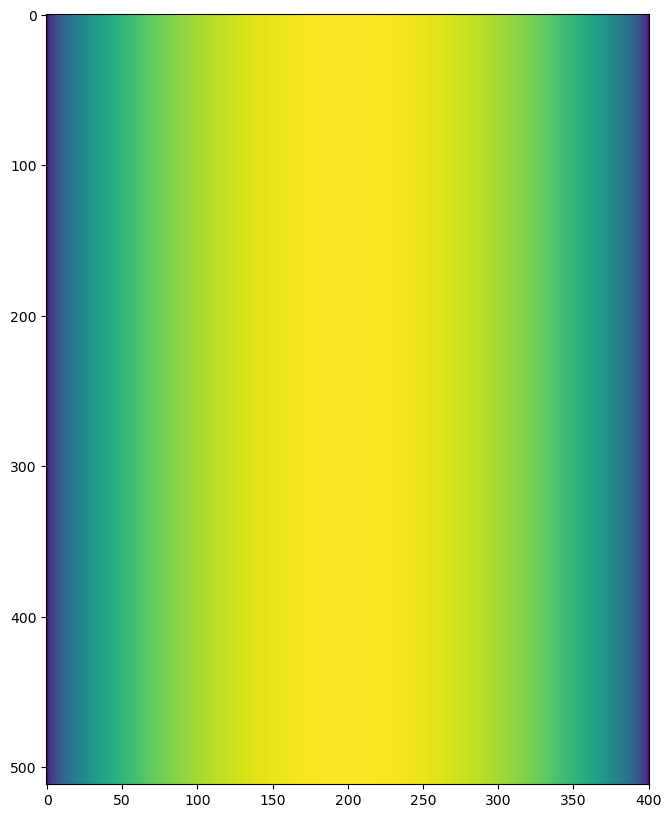

In [4]:
truncated_image = homogeneous_image[:, pixel_center-radius:pixel_center+radius+1]
[height, new_width] = np.shape(truncated_image)

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(truncated_image)

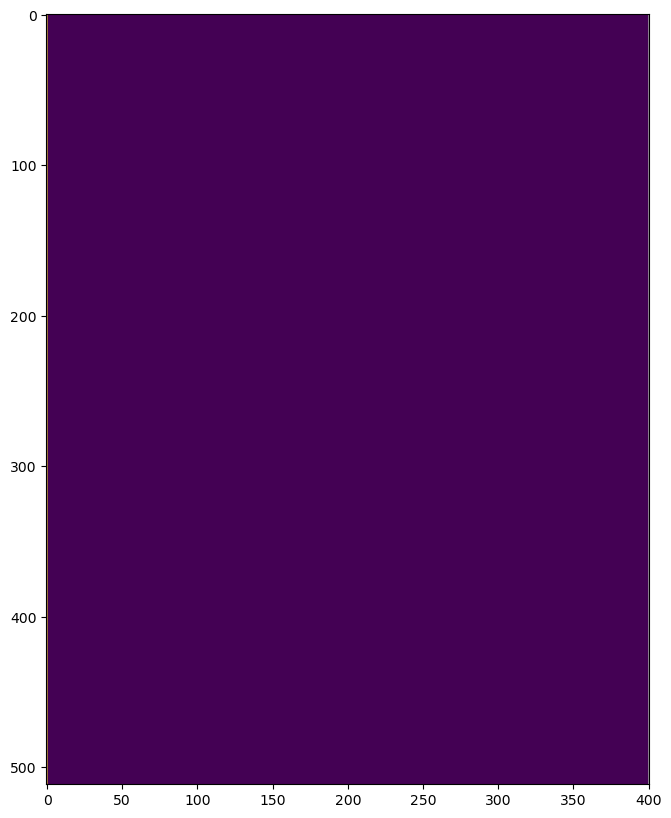

In [5]:
corrected_image = np.zeros([height, new_width])
for _h in np.arange(height):
    _expected_slice = []
    _slice = truncated_image[_h, :]
    for _index, _x in enumerate(np.arange(-radius, radius+1)):
        _input_data = _slice[_index]
        _coeff = geometry_correction.GeometryCorrection.homogeneous_correction(x=_x, radius=radius)
        _corrected_value = (_input_data * _coeff) / 2
#        _corrected_value = (_input_data * _coeff) / pixel_intensity
        _expected_slice.append(_corrected_value)
    corrected_image[_h, :] = _expected_slice

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(corrected_image)

### Test Result by Plotting a Slice

In [6]:
trace = go.Scatter(y=corrected_image[50,1:])
layout = go.Layout(title="Profile of row # 50",
                  xaxis=dict(title="width"),
                  yaxis=dict(title="Total Counts"))
figure=go.Figure(data=[trace], layout=layout)
iplot(figure)

### Put Back Object Inside Image

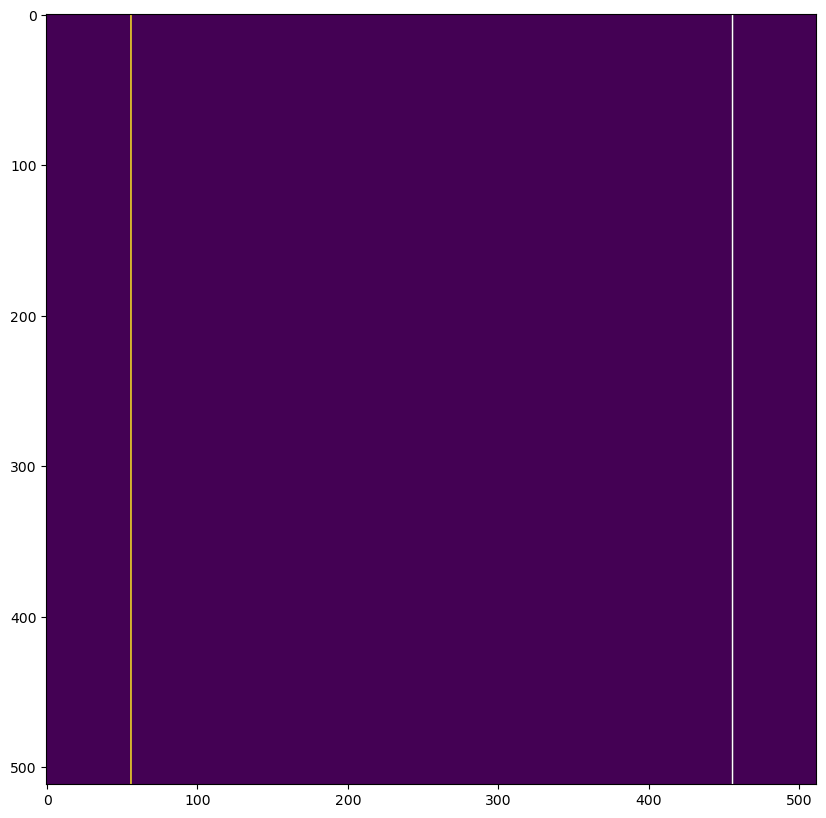

In [7]:
homogeneous_image[:, pixel_center-radius:pixel_center+radius+1] = corrected_image

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(homogeneous_image)


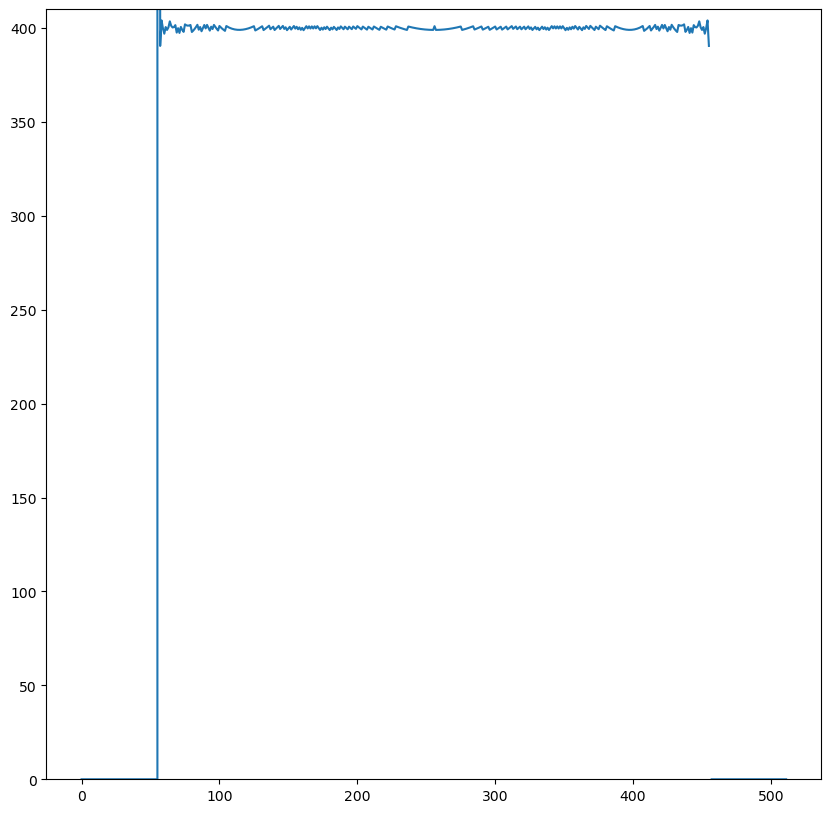

In [8]:
fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.set_ylim([0,410])
ax_img.plot(homogeneous_image[50,:])

### Output Corrected Image

In [9]:
output_file_name = 'data/corrected_homogeneous_image.fits'
file_handler.make_fits(homogeneous_image, output_file_name)

# Working with Inomogeneous Image

## Data of Interest are in the Outer Ring

Data are in the Outer Ring and the Inner Ring is empty

### Load and Preview of data

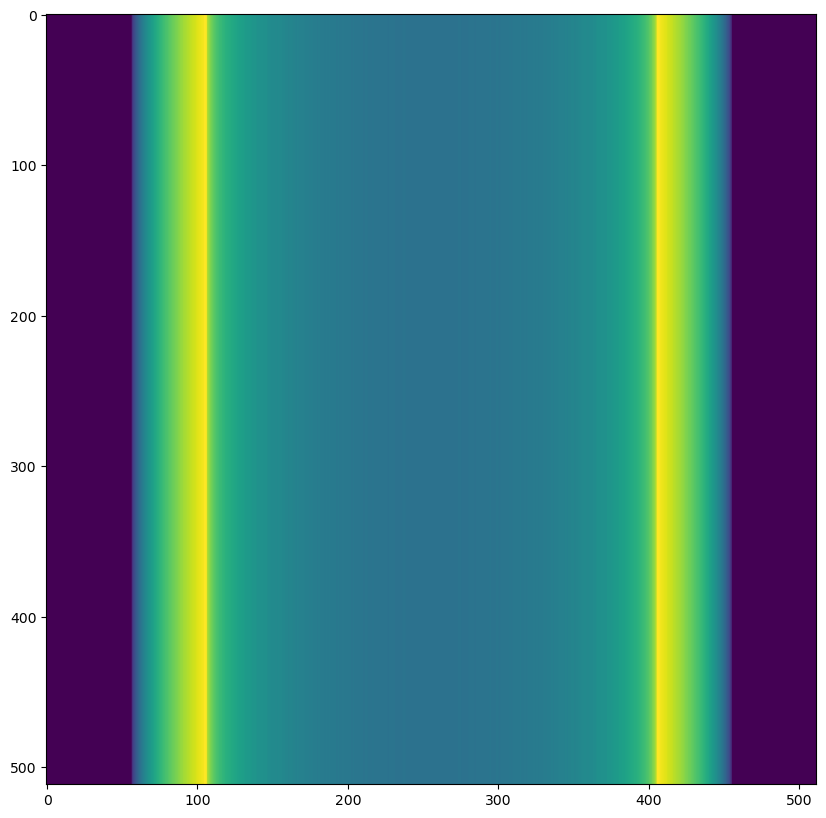

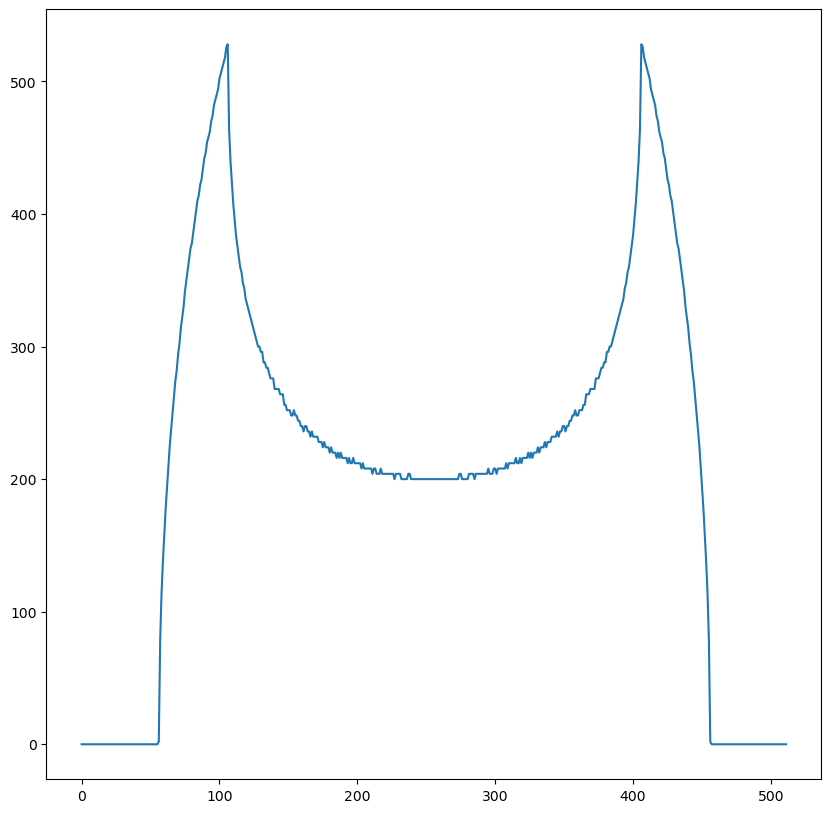

In [10]:
test_inhomogeneous_file = 'data/fits/inhomogeneous_image_px_intensity_2.fits'
inhomogeneous_image = file_handler.load_fits(test_inhomogeneous_file)

#test_homogeneous_file = 'data/homogeneous_image.tif'
#homogeneous_image = file_handler.load_tiff(test_homogeneous_file)
#homogeneous_image = homogeneous_image[:,:,0]

fig =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(inhomogeneous_image)

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.plot(inhomogeneous_image[0,:])

### Retrieve or Define Data Characteristics 

In [11]:
#image size
[width, height] = np.shape(inhomogeneous_image)

# defined by user
pixel_center = 256
inner_radius = 150
outer_radius = 200

_projected_image = inhomogeneous_image[0,:]
pixel_intensity = _projected_image[pixel_center]/(2*(outer_radius-inner_radius))

print("Settings recovered and defined are:")
print("Pixel Center : {}".format(pixel_center))
print("Inner Radius: {}".format(inner_radius))
print("Outer Radius: {}".format(outer_radius))
print("Pixel Intensity: {}".format(pixel_intensity))

Settings recovered and defined are:
Pixel Center : 256
Inner Radius: 150
Outer Radius: 200
Pixel Intensity: 2.0


### Loop Over all Slices and Correct Geometry

#### Truncate Data to Keep Only Object

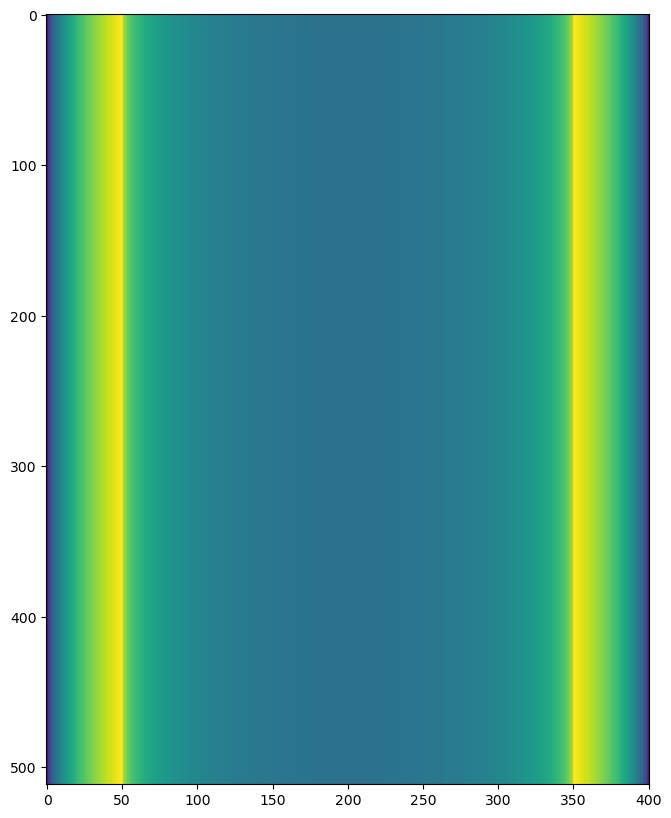

In [12]:
truncated_image = inhomogeneous_image[:, pixel_center-outer_radius:pixel_center+outer_radius+1]
[height, new_width] = np.shape(truncated_image)

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(truncated_image)

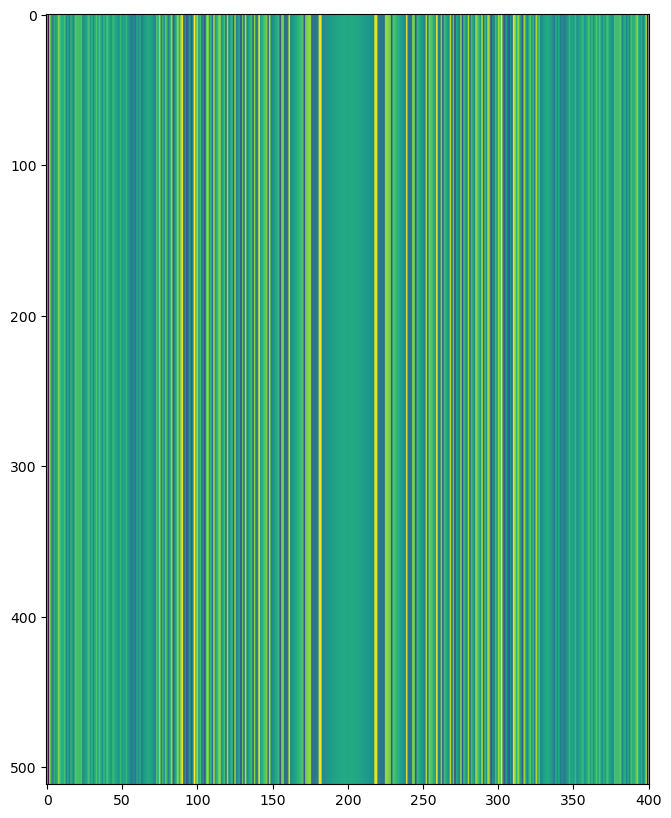

In [13]:
corrected_image = np.zeros([height, new_width])
for _h in np.arange(height):
    _expected_slice = []
    _slice = truncated_image[_h, :]
    for _index, _x in enumerate(np.arange(-outer_radius, outer_radius+1)):
        _input_data = _slice[_index]
        _coeff = geometry_correction.GeometryCorrection.inhomogeneous_correction(x=_x, inner_radius=inner_radius, outer_radius=outer_radius)
#        _corrected_value = (_input_data * _coeff) / pixel_intensity
        _corrected_value = (_input_data * _coeff) / 2
        _expected_slice.append(_corrected_value)
    corrected_image[_h, :] = _expected_slice

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(corrected_image)

#### Test Result by Plotting a Slice

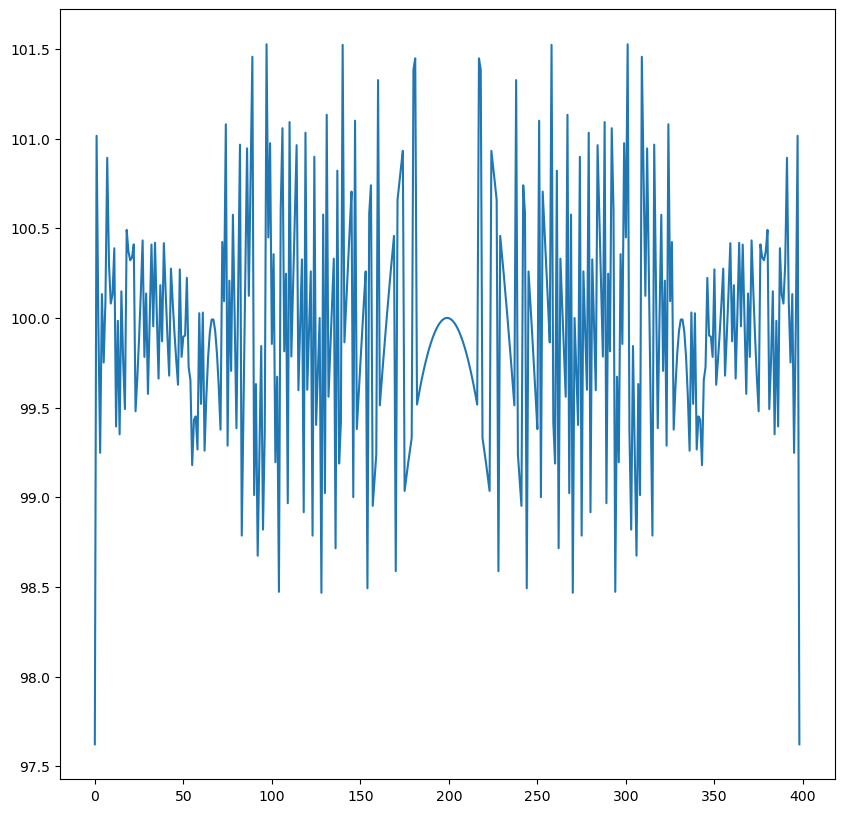

In [14]:
fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.plot(corrected_image[50, 1:])

#### Put Back Object Inside Image

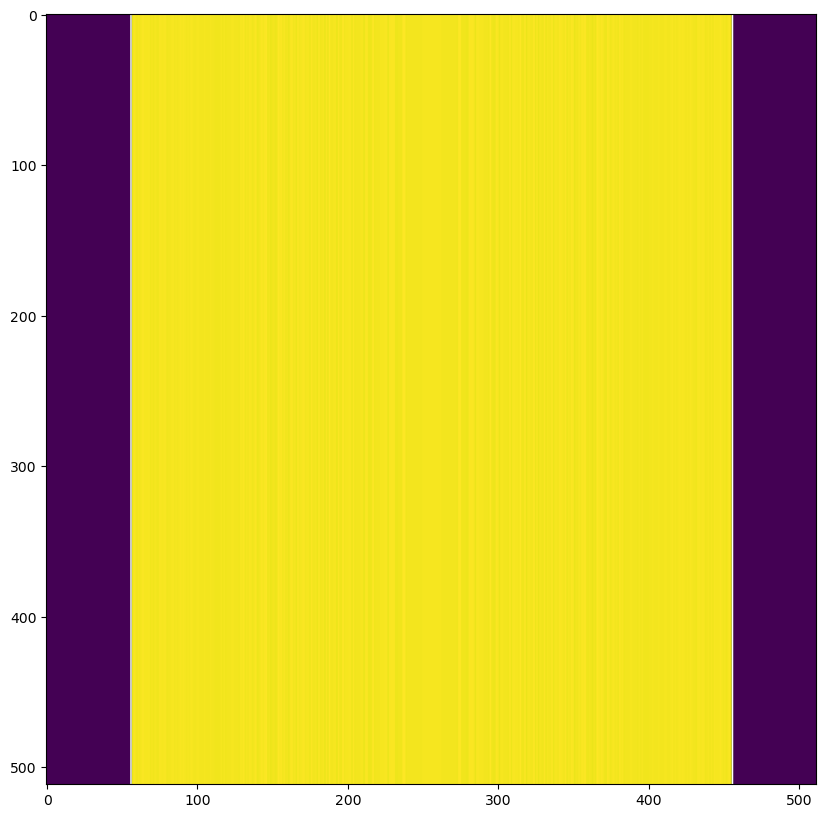

In [15]:
inhomogeneous_image[:, pixel_center-outer_radius:pixel_center+outer_radius+1] = corrected_image

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(inhomogeneous_image)

### Output Corrected Image

In [16]:
output_file_name = 'data/corrected_inhomogeneous_image.fits'
file_handler.make_fits(inhomogeneous_image, output_file_name)

## Data of Interest are in the Inner Cylinder 

Data are in the inner cylinder. Algorithm will use the edge of the outer cylinder to figure out the average (constant) count of this ring.

### Load and Preview of data

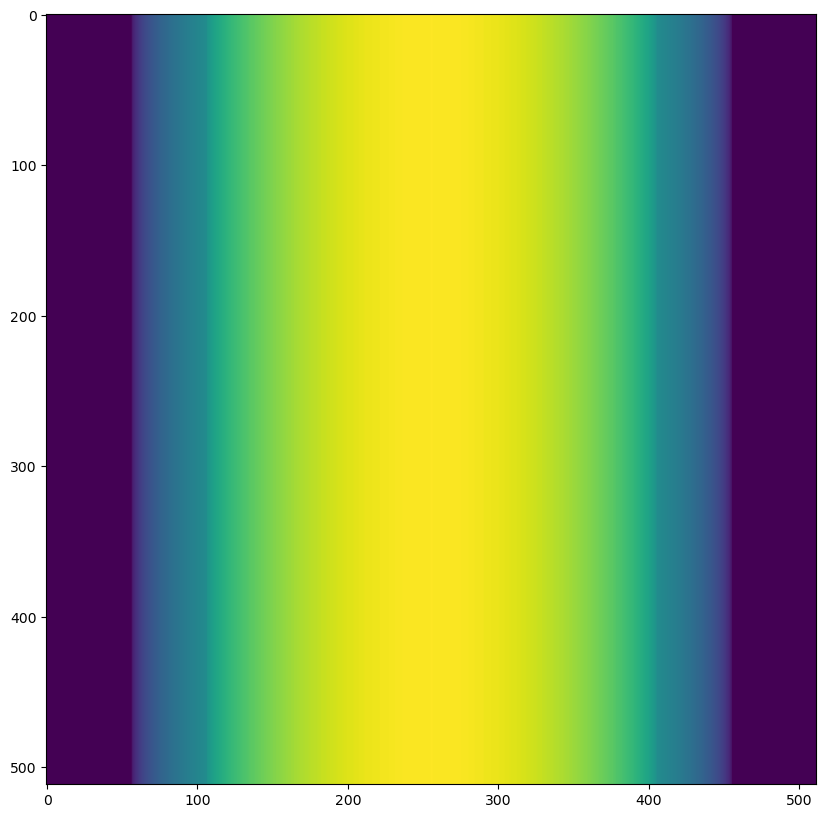

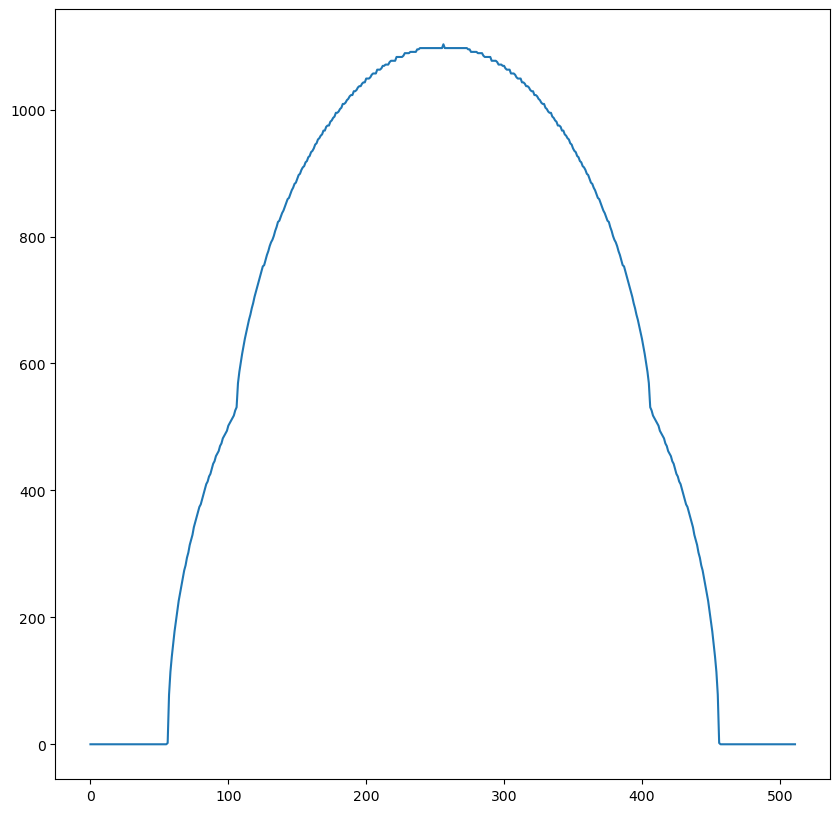

In [17]:
test_inhomogeneous_file = 'data/inhomogeneous_image_px_inner_intensity_3_px_outer_intensity_2.fits'
inhomogeneous_image = file_handler.load_fits(test_inhomogeneous_file)

#test_homogeneous_file = 'data/homogeneous_image.tif'
#homogeneous_image = file_handler.load_tiff(test_homogeneous_file)
#homogeneous_image = homogeneous_image[:,:,0]

fig =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(inhomogeneous_image)

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.plot(inhomogeneous_image[0,:])

### Retrieve or Define Data Characteristics 

In [18]:
def get_average_outer_pixel_intensity(inner_radius=-1, outer_radius=-1, pixel_center=-1, data=[]):
    
    pixel_range_left = np.arange(pixel_center - outer_radius, pixel_center - inner_radius)
    left_pixel_intensity = []
    for _pixel_position in pixel_range_left[1:-1]:
        _d = get_projected_lenght_at_position(pixel_position=_pixel_position,
                                              pixel_center=pixel_center,
                                             inner_radius=inner_radius,
                                              outer_radius=outer_radius)
        
        _pixel_intensity = data[int(_pixel_position)] / _d
        left_pixel_intensity.append(_pixel_intensity)
        
    mean_intensity = np.mean(left_pixel_intensity)
    min_intensity = np.min(left_pixel_intensity)
    max_intensity = np.max(left_pixel_intensity)
    
    error = np.max([np.abs(mean_intensity - min_intensity), np.abs(mean_intensity - max_intensity)])
        
    return [mean_intensity, error]

def get_projected_lenght_at_position(pixel_position=-1, pixel_center=-1, inner_radius=-1, outer_radius=-1):
    _d = 2*outer_radius*np.sin(np.arccos(np.abs(pixel_center - pixel_position)/outer_radius))
    return _d

In [19]:
#image size
[width, height] = np.shape(inhomogeneous_image)

# defined by user
pixel_center = 256
inner_radius = 150
outer_radius = 200

_projected_image = inhomogeneous_image[0,:]

[outer_pixel_intensity, outer_error_intensity] = get_average_outer_pixel_intensity(inner_radius=inner_radius, 
                                                         outer_radius=outer_radius, 
                                                         pixel_center=pixel_center, 
                                                         data=_projected_image)

#inner_pixel_intensity = (_projected_image[pixel_center] - (outer_pixel_intensity * 2 * (outer_radius - inner_radius))) / (2*inner_radius)

print("Settings recovered and defined are:")
print("Pixel Center : {}".format(pixel_center))
print("Inner Radius: {}".format(inner_radius))
print("Outer Radius: {}".format(outer_radius))
#print("Inner Pixel Intensity: {}".format(inner_pixel_intensity))
print("Outer Pixel Intensity: {:.02f}+/-{:.02f}".format(outer_pixel_intensity, outer_error_intensity))

Settings recovered and defined are:
Pixel Center : 256
Inner Radius: 150
Outer Radius: 200
Outer Pixel Intensity: 2.00+/-0.05


### Loop Over all Slices and Correct Geometry

#### Truncate Data to Keep Only Object

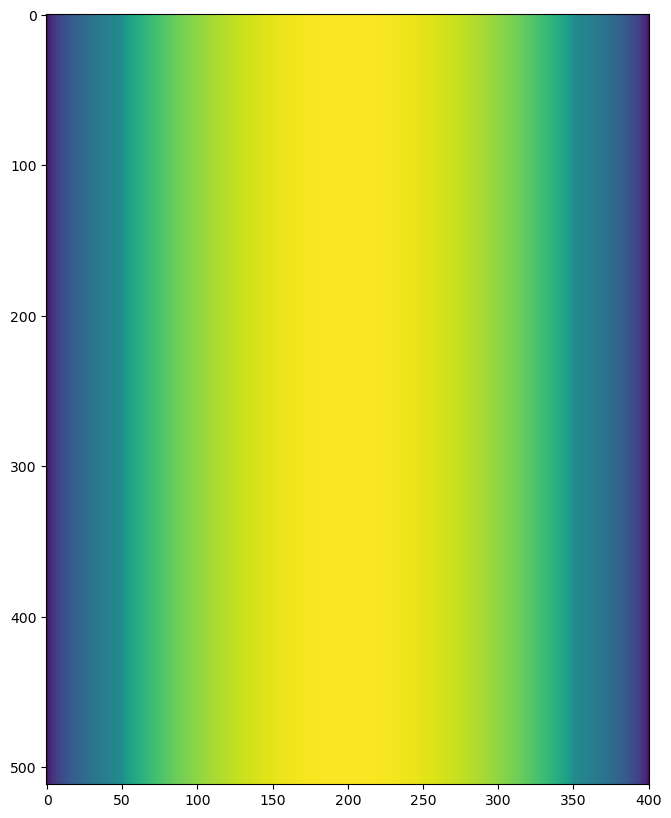

In [20]:
truncated_image = inhomogeneous_image[:, pixel_center-outer_radius:pixel_center+outer_radius+1]
[height, new_width] = np.shape(truncated_image)

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(truncated_image)

In [21]:
Image(url="images/inhomogeneous_cylinder_inner_and_outer_material_calculation_detail.png", width=750, height=750, unconfined=True)

In [22]:
corrected_image = np.zeros([height, 2*outer_radius])

_h = 0 # for debugging only

for _h in np.arange(height):
    step = 1 # for debugging only, otherwise try 0.1 or 0.01
    _expected_slice = []
    _slice = truncated_image[_h, :]

    _range = np.arange(0, new_width/2 - inner_radius)
    for _index, _x in enumerate(_range[1:]):
        _input_data = _slice[int(_x)]
        _pos = outer_radius-_x
        _coeff = geometry_correction.GeometryCorrection.homogeneous_correction(x=_pos, radius=outer_radius)
        _corrected_value = (_input_data * _coeff) / 2
        _expected_slice.append(_corrected_value)
        
    _range = np.arange(new_width/2 - inner_radius, new_width/2, step)
    for _index, _x in enumerate(_range):

        _x_length = new_width/2 - _x
        _input_data = _slice[int(_x)]

        _xi = 2* inner_radius * np.sin(np.arccos(_x_length/inner_radius))
        _xo = 2* outer_radius * np.sin(np.arccos(_x_length/outer_radius)) - _xi

        _ring_intensity = _xo * outer_pixel_intensity

        _coeff = geometry_correction.GeometryCorrection.homogeneous_correction(x=_x_length, radius=inner_radius)

        #print("_x:{}, _coeff:{}".format(_x, _coeff))
        _corrected_value = ((_input_data - _ring_intensity) * _coeff) / 2
        _expected_slice.append(_corrected_value)

    _range = np.arange(new_width/2, new_width/2 + inner_radius, step)
    for _index, _x in enumerate(_range):

        _x_length = new_width/2 - _x
        _input_data = _slice[int(_x)]

        _xi = 2* inner_radius * np.sin(np.arccos(_x_length/inner_radius))
        _xo = 2* outer_radius * np.sin(np.arccos(_x_length/outer_radius)) - _xi

        _ring_intensity = _xo * outer_pixel_intensity

        _coeff = geometry_correction.GeometryCorrection.homogeneous_correction(x=_x_length, radius=inner_radius)

        #print("_x:{}, _coeff:{}".format(_x, _coeff))
        _corrected_value = ((_input_data - _ring_intensity) * _coeff) / 2
        _expected_slice.append(_corrected_value)
        
    _range = np.arange(new_width/2 + inner_radius, new_width)
    for _index, _x in enumerate(_range[1:]):
        _input_data = _slice[int(_x)]
        _pos = _x - new_width/2
        _coeff = geometry_correction.GeometryCorrection.homogeneous_correction(x=_pos, radius=outer_radius)
        _corrected_value = (_input_data * _coeff) / 2
        _expected_slice.append(_corrected_value)
    
    corrected_image[_h, :] = _expected_slice

#### Test Result by Plotting a Slice

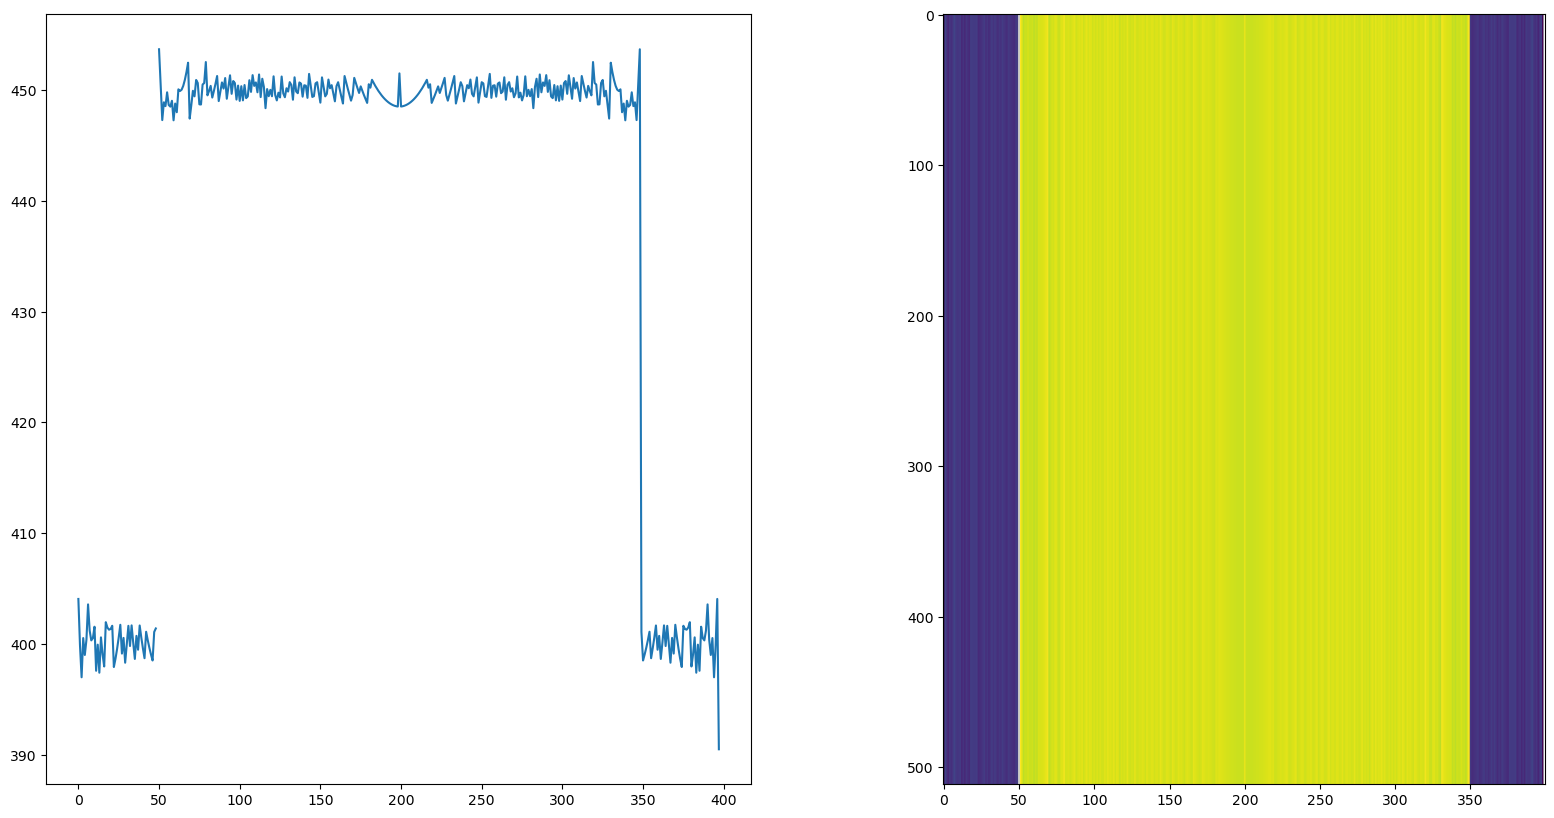

In [23]:
fig1 =  plt.figure(figsize=(20,10))
ax_img = plt.subplot(121)
ax_img.plot(corrected_image[50, 1:])


ax_img = plt.subplot(122)
ax_img.imshow(corrected_image)


#### Put Back Object Inside Image

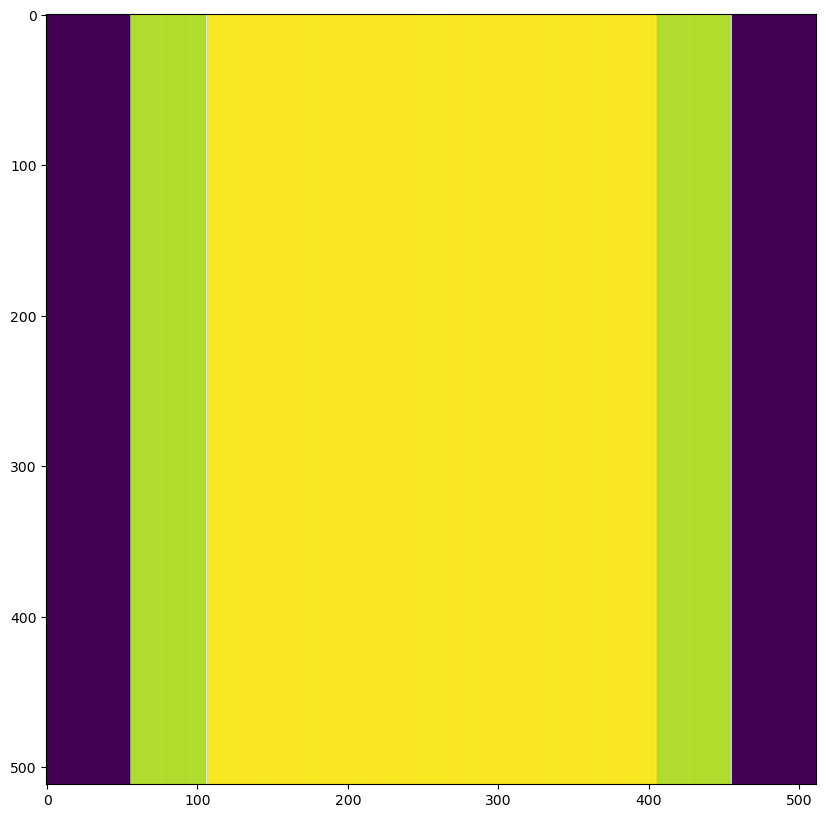

In [24]:
#inhomogeneous_image[:, pixel_center-inner_radius:pixel_center+inner_radius] = corrected_image
inhomogeneous_image[:, pixel_center-outer_radius:pixel_center+outer_radius] = corrected_image

fig1 =  plt.figure(figsize=(10,10))
ax_img = plt.subplot(111)
ax_img.imshow(inhomogeneous_image)

### Output Corrected Image

In [25]:
output_file_name = 'data/corrected_inhomogeneous_image_inner_material.fits'
file_handler.make_fits(inhomogeneous_image, output_file_name)